# HiddenExtension 격자 PM10 추론 결과 시각화

`inference.py` 실행 후 저장된 결과를 불러와 시각화합니다.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

# ── 설정: 보고 싶은 실험 폴더명 ──────────────────────────────────────────
CKPT_DIR  = "xall_attnfull_lurlinear_r8_lam0.5"   # 변경 가능
BASE_PATH = os.path.join(os.path.dirname(os.getcwd()), "HiddenExtension2", "checkpoints", CKPT_DIR)
GRID_CSV  = "/home/data/youngwoong/ST-GNN_Dataset/Data_Preprocessed/Land Use Regression/격자 기본/격자_250m_4326.csv"
TIME_PATH = "/home/data/youngwoong/ST-GNN_Dataset/Data_Preprocessed/Land Use Regression/격자 기본/timestamps_all.npy"
TIME_IDX_TEST = "/home/data/youngwoong/ST-GNN_Dataset/Data_Preprocessed/Land Use Regression/격자 기본/time_idx_test.npy"
STGNN_WINDOW = 12

# ── 데이터 로드 ──────────────────────────────────────────────────────────
all_pm     = np.load(os.path.join(BASE_PATH, 'grid_pm10_predictions.npy'))  # [T, G]
mean_csv   = pd.read_csv(os.path.join(BASE_PATH, 'grid_pm10_mean.csv'))
grid_basic = pd.read_csv(GRID_CSV)

ts_all         = pd.to_datetime(np.load(TIME_PATH, allow_pickle=True))
time_idx_test  = np.load(TIME_IDX_TEST)
target_idx     = time_idx_test[STGNN_WINDOW:]
timestamps     = ts_all[target_idx]   # 테스트 기간 타임스텝

lon = grid_basic['lon'].values
lat = grid_basic['lat'].values
T, G = all_pm.shape

print(f"로드 완료: {T}개 타임스텝 × {G}개 격자")
print(f"기간: {timestamps[0]} ~ {timestamps[-1]}")
print(f"PM10 범위: {all_pm.min():.1f} ~ {all_pm.max():.1f} μg/m³")


로드 완료: 2732개 타임스텝 × 10125개 격자
기간: 2025-07-10 04:00:00 ~ 2025-10-31 23:00:00
PM10 범위: -0.7 ~ 122.5 μg/m³


## 1. 서울 전역 시간평균 PM10 분포

/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 49436 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 50872 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 49884 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 44036 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 54217 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 44512 missing from current font.
  font.set_

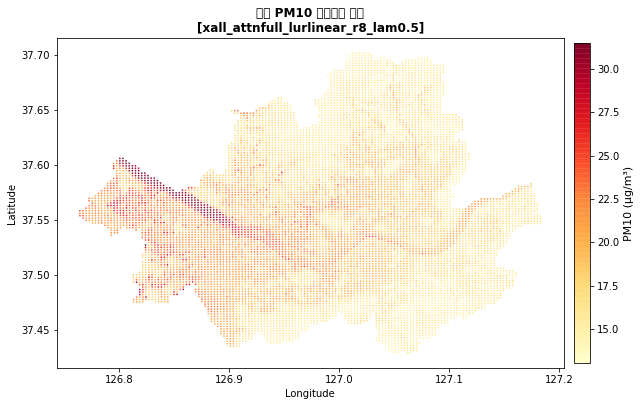

In [3]:
mean_pm = all_pm.mean(axis=0)
vmin, vmax = mean_pm.min(), np.percentile(mean_pm, 99)

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(lon, lat, c=mean_pm, cmap='YlOrRd',
                vmin=vmin, vmax=vmax, s=3, linewidths=0, alpha=0.9)
cb = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('PM10 (μg/m³)', fontsize=11)
ax.set_title(f'서울 PM10 시간평균 분포\n[{CKPT_DIR}]', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'grid_pm10_mean.png'), dpi=150, bbox_inches='tight')
plt.show()


## 2. 저/중/고/최고 농도 시각 스냅샷

/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 51200 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 45453 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 46020 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 51473 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 44256 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 52572 missing from current font.
  font.set_

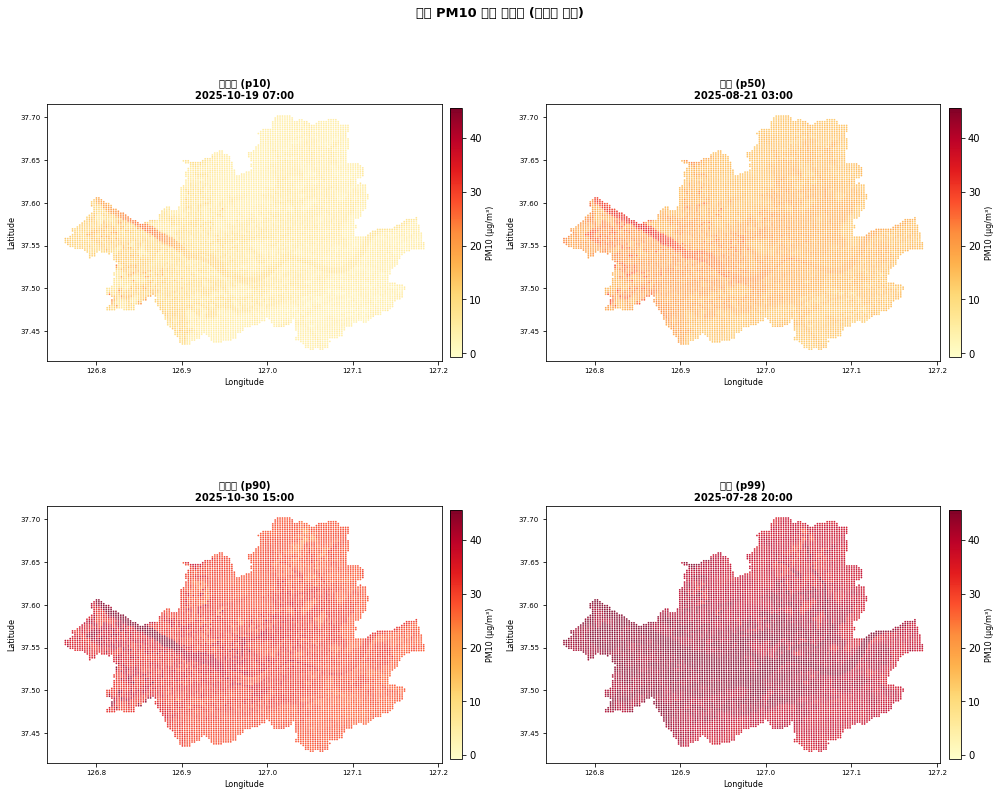

In [4]:
hourly_mean = all_pm.mean(axis=1)   # [T]
pcts   = [10, 50, 90, 99]
titles = ['저농도 (p10)', '중간 (p50)', '고농도 (p90)', '최고 (p99)']
idxs   = [int(np.argmin(np.abs(hourly_mean - np.percentile(hourly_mean, p)))) for p in pcts]

vmin_s = all_pm.min()
vmax_s = np.percentile(all_pm, 99)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('서울 PM10 농도 스냅샷 (테스트 기간)', fontsize=13, fontweight='bold')

for ax, idx, title in zip(axes.flat, idxs, titles):
    ts_label = str(timestamps[idx])[:16]
    sc = ax.scatter(lon, lat, c=all_pm[idx], cmap='YlOrRd',
                    vmin=vmin_s, vmax=vmax_s, s=3, linewidths=0, alpha=0.9)
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02).set_label('PM10 (μg/m³)', fontsize=8)
    ax.set_title(f'{title}\n{ts_label}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=8); ax.set_ylabel('Latitude', fontsize=8)
    ax.set_aspect('equal'); ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'grid_pm10_snapshots.png'), dpi=150, bbox_inches='tight')
plt.show()


## 3. 서울 전체 PM10 시계열 (공간 평균)

/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 53580 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 49828 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 53944 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 53440 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 51076 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 53597 missing from current font.
  font.set_

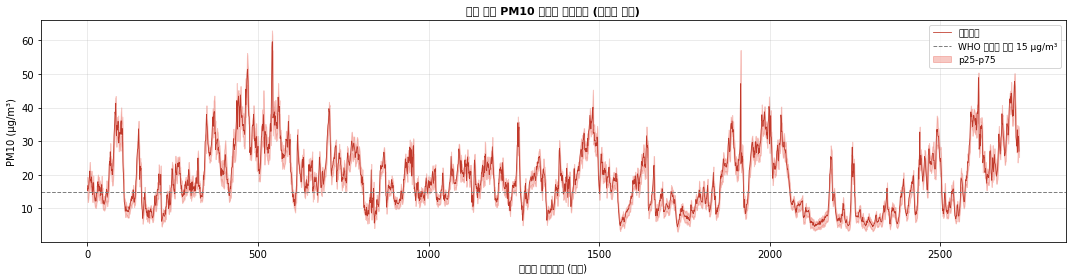

In [5]:
hourly_mean = all_pm.mean(axis=1)
hourly_p25  = np.percentile(all_pm, 25, axis=1)
hourly_p75  = np.percentile(all_pm, 75, axis=1)

fig, ax = plt.subplots(figsize=(15, 4))
ax.fill_between(range(T), hourly_p25, hourly_p75, alpha=0.3, color='#e74c3c', label='p25-p75')
ax.plot(hourly_mean, color='#c0392b', linewidth=0.8, label='공간평균')
ax.axhline(15, color='gray', linewidth=1, linestyle='--', label='WHO 연평균 기준 15 μg/m³')
ax.set_xlabel('테스트 타임스텝 (시간)', fontsize=10)
ax.set_ylabel('PM10 (μg/m³)', fontsize=10)
ax.set_title('서울 전역 PM10 시간별 공간평균 (테스트 기간)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'grid_pm10_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()


## 4. PM10 농도 분포 (전체 격자×시간)

/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 44201 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 51088 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 49688 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 48516 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 54252 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.6/dist-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 52404 missing from current font.
  font.set_

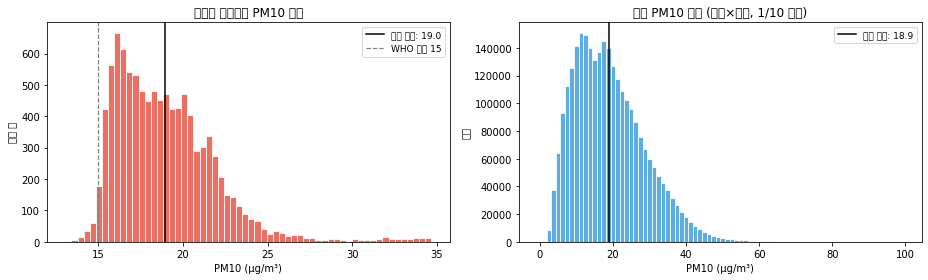

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 시간 평균 분포
axes[0].hist(mean_pm, bins=60, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0].axvline(mean_pm.mean(), color='black', linewidth=1.5, label=f'전체 평균: {mean_pm.mean():.1f}')
axes[0].axvline(15, color='gray', linewidth=1.2, linestyle='--', label='WHO 기준 15')
axes[0].set_xlabel('PM10 (μg/m³)'); axes[0].set_ylabel('격자 수')
axes[0].set_title('격자별 시간평균 PM10 분포'); axes[0].legend(fontsize=9)

# 전체 분포 (샘플링)
flat_sample = all_pm.flatten()[::10]   # 1/10 샘플
axes[1].hist(flat_sample, bins=80, color='#3498db', alpha=0.8, edgecolor='white')
axes[1].axvline(flat_sample.mean(), color='black', linewidth=1.5, label=f'전체 평균: {flat_sample.mean():.1f}')
axes[1].set_xlabel('PM10 (μg/m³)'); axes[1].set_ylabel('빈도')
axes[1].set_title('전체 PM10 분포 (격자×시간, 1/10 샘플)'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'grid_pm10_histogram.png'), dpi=150, bbox_inches='tight')
plt.show()


## 5. 특정 날짜·시각 지도 (날짜 직접 지정)

가장 가까운 타임스텝: 2025-08-01 10:00:00  (인덱스 534)


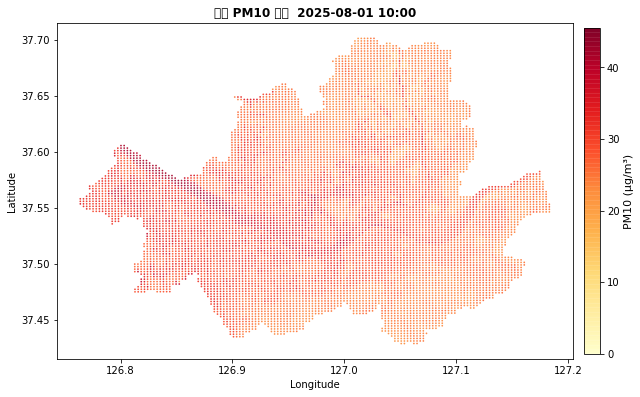

In [10]:
# 원하는 날짜·시각 입력
TARGET_TIME = "2025-08-01 10:00:00"   # 변경 가능

target_dt = pd.Timestamp(TARGET_TIME)
diffs = np.abs(timestamps - target_dt)
t_idx = int(np.argmin(diffs))
print(f"가장 가까운 타임스텝: {timestamps[t_idx]}  (인덱스 {t_idx})")

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(lon, lat, c=all_pm[t_idx], cmap='YlOrRd',
                vmin=0, vmax=np.percentile(all_pm, 99), s=3, linewidths=0, alpha=0.9)
plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02).set_label('PM10 (μg/m³)', fontsize=11)
ax.set_title(f'서울 PM10 분포  {timestamps[t_idx].strftime("%Y-%m-%d %H:%M")}', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_aspect('equal'); plt.tight_layout(); plt.show()


## 6. 서울 OpenStreetMap 인터랙티브 지도 (HTML 저장)

In [12]:
import folium
from folium.plugins import HeatMap
import branca.colormap as bcm
import plotly.graph_objects as go
import numpy as np, pandas as pd, os

# ── 측정소 정보 (좌표 + 이름) ────────────────────────────────────────────
WIND_CSV = '/home/data/youngwoong/ST-GNN_Dataset/Data_Preprocessed/ST-GNN/feature_scenarios/S7_transport_pm10_weather.csv'
COORDS_PATH = os.path.join(os.path.dirname(os.getcwd()), 'HiddenExtension', 'data', 'hidden_vectors', 'coords.npy')

coords_np = np.load(COORDS_PATH)  # [N, 2] lat, lon
sta_df_raw = pd.read_csv(WIND_CSV)
sta_info = sta_df_raw.groupby('측정소명')[['위도','경도','PM10']].agg({'위도':'first','경도':'first','PM10':'mean'}).reset_index()
sta_info.columns = ['name','lat','lon','pm10_mean_sta']

# ── 색상 스케일 ──────────────────────────────────────────────────────────
vmin_c = float(mean_pm.min())
vmax_c = float(np.percentile(mean_pm, 98))
PM10_COLORS = ['#FFFFB2','#FED976','#FEB24C','#FD8D3C','#FC4E2A','#E31A1C','#BD0026','#800026']

colormap = bcm.LinearColormap(
    colors=PM10_COLORS,
    vmin=vmin_c, vmax=vmax_c,
    caption='PM10 농도 (μg/m³)'
)

SEOUL_CENTER = [37.563, 126.979]
print(f'격자: {G}개  |  색상 범위: {vmin_c:.1f} ~ {vmax_c:.1f} μg/m³')


격자: 10125개  |  색상 범위: 13.1 ~ 26.9 μg/m³


### 6-A. Folium 히트맵 (부드러운 그라디언트)

In [13]:
def make_heatmap_layer(pm_values, name, show=True):
    """pm_values: [G] 배열 → folium FeatureGroup"""
    # 0~1 정규화 (히트맵 그라디언트 적용용)
    w = np.clip((pm_values - vmin_c) / (vmax_c - vmin_c + 1e-6), 0, 1)
    data = [[float(lat[g]), float(lon[g]), float(w[g])] for g in range(G)]
    fg = folium.FeatureGroup(name=name, show=show)
    HeatMap(
        data, min_opacity=0.55, radius=11, blur=9, max_zoom=14,
        gradient={0.0:'#FFFFB2', 0.3:'#FEB24C', 0.55:'#FC4E2A',
                  0.75:'#E31A1C', 1.0:'#800026'}
    ).add_to(fg)
    return fg

# ── 지도 생성 ─────────────────────────────────────────────────────────────
m = folium.Map(location=SEOUL_CENTER, zoom_start=11,
               tiles='OpenStreetMap', prefer_canvas=True)

# 레이어 추가
make_heatmap_layer(mean_pm,           '🌫️ 시간평균',       show=True ).add_to(m)
make_heatmap_layer(all_pm[idxs[0]],   '😊 맑은 날 (p10)',   show=False).add_to(m)
make_heatmap_layer(all_pm[idxs[1]],   '😐 보통 날 (p50)',   show=False).add_to(m)
make_heatmap_layer(all_pm[idxs[2]],   '😷 나쁜 날 (p90)',   show=False).add_to(m)
make_heatmap_layer(all_pm[idxs[3]],   '🚨 최악의 날 (p99)', show=False).add_to(m)

# ── 측정소 마커 ──────────────────────────────────────────────────────────
fg_sta = folium.FeatureGroup(name='📍 측정소', show=True)
for _, r in sta_info.iterrows():
    c = colormap(min(r.pm10_mean_sta, vmax_c))
    folium.CircleMarker(
        location=[r.lat, r.lon], radius=7,
        color='white', weight=2, fill=True,
        fill_color=c, fill_opacity=0.95,
        tooltip=folium.Tooltip(
            f"<div style='font-family:sans-serif;font-size:13px;'>"
            f"<b>{r['name']}</b><br>"
            f"PM10 평균: <b style='color:#c0392b'>{r.pm10_mean_sta:.1f} μg/m³</b>"
            f"</div>", sticky=True
        )
    ).add_to(fg_sta)
fg_sta.add_to(m)

# ── 컬러바 & 레이어 컨트롤 ───────────────────────────────────────────────
colormap.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# ── 타이틀 오버레이 ──────────────────────────────────────────────────────
title_html = f'''
<div style="position:fixed;top:12px;left:50%;transform:translateX(-50%);
     z-index:9999;background:rgba(255,255,255,0.93);
     padding:10px 22px;border-radius:10px;
     box-shadow:0 2px 10px rgba(0,0,0,0.25);text-align:center;">
  <div style="font-size:17px;font-weight:bold;color:#c0392b;">🌫️ 서울 PM10 농도 분포</div>
  <div style="font-size:11px;color:#555;margin-top:3px;">
    {timestamps[0].strftime("%Y-%m-%d")} ~ {timestamps[-1].strftime("%Y-%m-%d")} &nbsp;|&nbsp;
    HiddenExtension V2 &nbsp;|&nbsp; {CKPT_DIR}
  </div>
  <div style="font-size:10px;color:#888;margin-top:2px;">
    WHO 연평균 기준: 15 μg/m³ &nbsp;·&nbsp; 250m 격자 {G:,}개
  </div>
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

out_heatmap = os.path.join(BASE_PATH, 'grid_pm10_seoul_heatmap.html')
m.save(out_heatmap)
print(f'저장 완료 → {out_heatmap}')


저장 완료 → /workspace/ST-GNN Modeling/HiddenExtension2/checkpoints/xall_attnfull_lurlinear_r8_lam0.5/grid_pm10_seoul_heatmap.html


### 6-B. Plotly 격자별 정밀 지도 (hover 상세정보)

In [14]:
def make_plotly_map(pm_values, title_sub, timestamps_label=''):
    pm_clipped = np.clip(pm_values, vmin_c, vmax_c)
    hover_text = [
        f"<b>{grid_basic.iloc[g]['CELL_ID']}</b><br>"
        f"PM10: {pm_values[g]:.1f} μg/m³"
        for g in range(G)
    ]
    fig = go.Figure(go.Scattermapbox(
        lat=lat, lon=lon,
        mode='markers',
        marker=dict(
            size=5,
            color=pm_clipped,
            colorscale=[
                [0.00, '#FFFFB2'], [0.25, '#FEB24C'], [0.50, '#FC4E2A'],
                [0.75, '#E31A1C'], [1.00, '#800026']
            ],
            cmin=vmin_c, cmax=vmax_c,
            opacity=0.75,
            colorbar=dict(
                title='PM10<br>(μg/m³)', thickness=14, len=0.6,
                tickfont=dict(size=11),
                tickvals=[vmin_c, (vmin_c+vmax_c)/2, vmax_c],
                ticktext=[f'{vmin_c:.0f}', f'{(vmin_c+vmax_c)/2:.0f}', f'{vmax_c:.0f}']
            )
        ),
        text=hover_text, hoverinfo='text',
    ))

    # 측정소 마커
    fig.add_trace(go.Scattermapbox(
        lat=sta_info['lat'], lon=sta_info['lon'],
        mode='markers+text',
        marker=dict(size=10, color='white',
                    line=dict(width=2, color='#c0392b')),
        text=sta_info['name'],
        textposition='top right',
        textfont=dict(size=9, color='#333'),
        hovertext=[f"<b>{r['name']}</b><br>PM10: {r.pm10_mean_sta:.1f} μg/m³"
                   for _, r in sta_info.iterrows()],
        hoverinfo='text', name='측정소'
    ))

    fig.update_layout(
        mapbox=dict(
            style='open-street-map',
            center=dict(lat=37.563, lon=126.979),
            zoom=10.5
        ),
        margin=dict(l=0, r=0, t=50, b=0),
        height=750,
        title=dict(
            text=f'🌫️ 서울 PM10 농도 분포 · {title_sub}'
                 f'<br><sup style="color:#888">{timestamps_label} | {CKPT_DIR}</sup>',
            x=0.5, xanchor='center',
            font=dict(size=16, color='#c0392b')
        ),
        paper_bgcolor='white',
        showlegend=False,
    )
    return fig

# ── 탭 버튼으로 5개 레이어 전환하는 단일 HTML ───────────────────────────
from plotly.subplots import make_subplots

snap_configs = [
    (mean_pm,         '시간평균',
     f"{timestamps[0].strftime('%Y-%m-%d')} ~ {timestamps[-1].strftime('%Y-%m-%d')}"),
    (all_pm[idxs[0]], f'맑은 날 (p10)',   str(timestamps[idxs[0]])[:16]),
    (all_pm[idxs[1]], f'보통 날 (p50)',   str(timestamps[idxs[1]])[:16]),
    (all_pm[idxs[2]], f'나쁜 날 (p90)',   str(timestamps[idxs[2]])[:16]),
    (all_pm[idxs[3]], f'최악의 날 (p99)', str(timestamps[idxs[3]])[:16]),
]

# 버튼으로 레이어 전환하는 단일 fig
fig = make_plotly_map(*snap_configs[0])

# updatemenus 버튼 추가
buttons = []
for i, (pm_vals, label, ts_label) in enumerate(snap_configs):
    pm_clipped = np.clip(pm_vals, vmin_c, vmax_c).tolist()
    hover = [f"<b>{grid_basic.iloc[g]['CELL_ID']}</b><br>PM10: {pm_vals[g]:.1f} μg/m³" for g in range(G)]
    buttons.append(dict(
        label=label,
        method='restyle',
        args=[{'marker.color': [pm_clipped, None],
               'text': [hover, None]}, [0]]
    ))

fig.update_layout(updatemenus=[dict(
    type='buttons', direction='right',
    x=0.5, xanchor='center', y=1.08, yanchor='top',
    bgcolor='white', bordercolor='#ccc', borderwidth=1,
    font=dict(size=12),
    buttons=buttons
)])

out_plotly = os.path.join(BASE_PATH, 'grid_pm10_seoul_interactive.html')
fig.write_html(out_plotly, include_plotlyjs='cdn')
print(f'저장 완료 → {out_plotly}')
fig.show()


ValueError: Invalid property specified for object of type plotly.graph_objs.scattermapbox.Marker: 'line'

Did you mean "size"?

    Valid properties:
        allowoverlap
            Flag to draw all symbols, even if they overlap.
        angle
            Sets the marker orientation from true North, in degrees
            clockwise. When using the "auto" default, no rotation
            would be applied in perspective views which is
            different from using a zero angle.
        anglesrc
            Sets the source reference on Chart Studio Cloud for
            `angle`.
        autocolorscale
            Determines whether the colorscale is a default palette
            (`autocolorscale: true`) or the palette determined by
            `marker.colorscale`. Has an effect only if in
            `marker.color` is set to a numerical array. In case
            `colorscale` is unspecified or `autocolorscale` is
            true, the default palette will be chosen according to
      